In [287]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [288]:
words = open('names.txt', 'r').read().splitlines()

In [289]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [290]:
import random
random.seed(42)
random.shuffle(words)

In [291]:
block_size = 8 # context length
def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [366]:
# -----------------------------------------------------------------------------------------------
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
    
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
      
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:

    def __init__(self, num_embeddings, embeddings_dim):
        self.weight = torch.randn((num_embeddings, embeddings_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]

# -----------------------------------------------------------------------------------------------
class Flatten:

    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out

    def parameters(self):
        return []

# -----------------------------------------------------------------------------------------------
class FlattenConsecutive:

    def __init__(self, n): # how many conseq penultimate dim elements to concat in last dim
        self.n = n

    def __call__(self, x):
        # B -> Batch (examples dim)
        # T -> Time (tokens/positions dim)
        # C -> Channels (features dim)
        B, T, C = x.shape
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out

    def parameters(self):
        return []
        
# -----------------------------------------------------------------------------------------------
class Sequential:
  
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [367]:
torch.manual_seed(42);

In [386]:
n_embd = 10  
n_hidden = 68  

model = Sequential([
    Embedding(vocab_size, n_embd),
    # ---
    FlattenConsecutive(2),
    Linear(n_embd * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    # ---
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    # ---
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    # ---
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    layers[-1].weight *= 0.1 

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

22397


In [387]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update: simple SGD
    lr = 0.1 if i < 150000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    

      0/ 200000: 3.3026
  10000/ 200000: 2.0709
  20000/ 200000: 1.8319
  30000/ 200000: 2.2986
  40000/ 200000: 2.3780
  50000/ 200000: 1.9172
  60000/ 200000: 2.3329
  70000/ 200000: 1.6861
  80000/ 200000: 2.2019
  90000/ 200000: 2.3421
 100000/ 200000: 2.1560
 110000/ 200000: 1.8572
 120000/ 200000: 1.6889
 130000/ 200000: 1.8546
 140000/ 200000: 1.9911
 150000/ 200000: 1.9944
 160000/ 200000: 1.9312
 170000/ 200000: 2.0439
 180000/ 200000: 2.0806
 190000/ 200000: 1.7124


200000

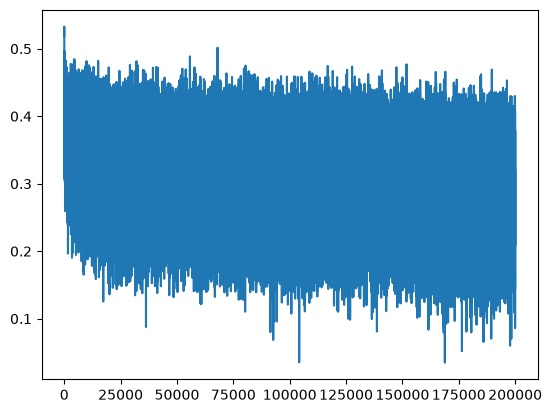

In [388]:
plt.plot(lossi);
len(lossi)

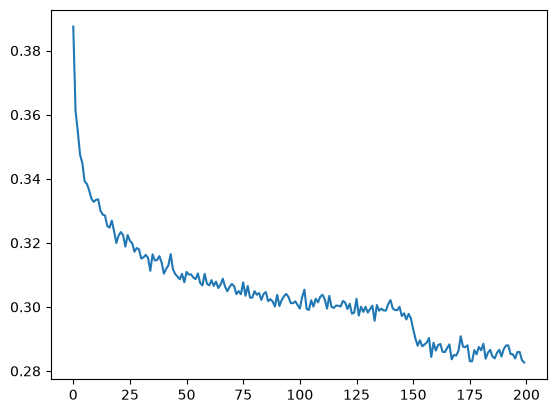

In [389]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1));

In [390]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [391]:
@torch.no_grad() 
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val':   (Xdev, Ydev),
        'test':  (Xte, Yte),
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9100748300552368
val 2.017902135848999


In [392]:
# sample from the model

for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
        # forward pass the neural Çnet
        logits = model(torch.tensor([context])) # add batch dim!
        probs = F.softmax(logits, dim=1)

        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()

        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)

        # if we sample the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))  # decode and print the generated word

felicho.
senna.
maliah.
derrian.
daivin.
inovaa.
hamer.
grealynn.
myrsh.
kee.
andry.
azi.
stefrog.
avertt.
haley.
hagaya.
elia.
britlynn.
adeianne.
kolzah.


## Shapes

In [320]:
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
Xb.shape, logits.shape

(torch.Size([4, 8]), torch.Size([4, 27]))

In [321]:
model.layers[0].out.shape # output of embedding layer

torch.Size([4, 8, 10])

In [322]:
model.layers[1].out.shape # output of flatten layer

torch.Size([4, 4, 20])

In [323]:
model.layers[2].out.shape # output of linear layer

torch.Size([4, 4, 68])

In [324]:
# linear layer demo
d = torch.randn(4, 80) @ torch.randn(80, 200) + torch.randn(200) 
d.shape

torch.Size([4, 200])

In [325]:
# linear layer demo
d = torch.randn(4, 5, 80) @ torch.randn(80, 200) + torch.randn(200) 
d.shape

torch.Size([4, 5, 200])

In [326]:
d = torch.randn(4, 4, 20) @ torch.randn(20, 200) + torch.randn(200) 
d.shape

torch.Size([4, 4, 200])

In [327]:
e = torch.randn(4, 8, 10) # -> flatten to (4, 4, 20)
e.shape

torch.Size([4, 8, 10])

In [328]:
list(range(10))[1::2]

[1, 3, 5, 7, 9]

In [329]:
list(range(10))[::2]

[0, 2, 4, 6, 8]

In [330]:
e[:, ::2, :].shape

torch.Size([4, 4, 10])

In [331]:
e[:, 1::2, :].shape

torch.Size([4, 4, 10])

In [332]:
explicit = torch.cat((e[:, ::2, :], e[:, 1::2, :]), dim=2)
explicit.shape

torch.Size([4, 4, 20])

In [333]:
(e.view(4, 4, 20) == explicit).all()

tensor(True)

In [334]:
# ----
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
Xb.shape, logits.shape

(torch.Size([4, 8]), torch.Size([4, 27]))

In [335]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1d : (4, 4, 68)
Tanh : (4, 4, 68)
FlattenConsecutive : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1d : (4, 2, 68)
Tanh : (4, 2, 68)
FlattenConsecutive : (4, 136)
Linear : (4, 68)
BatchNorm1d : (4, 68)
Tanh : (4, 68)
Linear : (4, 27)


In [374]:
# ----
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
Xb.shape, logits.shape

(torch.Size([4, 8]), torch.Size([4, 27]))

In [375]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1d : (4, 4, 68)
Tanh : (4, 4, 68)
FlattenConsecutive : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1d : (4, 2, 68)
Tanh : (4, 2, 68)
FlattenConsecutive : (4, 136)
Linear : (4, 68)
BatchNorm1d : (4, 68)
Tanh : (4, 68)
Linear : (4, 27)


## Fix batchnorm 3d

In [402]:
e = torch.randn(32, 4, 68)
emean = e.mean(0, keepdim=True)
evar = e.var(0, keepdim=True)
ehat = (e - emean) / torch.sqrt(evar + 1e-5)

e.shape, emean.shape, evar.shape, ehat.shape

(torch.Size([32, 4, 68]),
 torch.Size([1, 4, 68]),
 torch.Size([1, 4, 68]),
 torch.Size([32, 4, 68]))

In [356]:
# we whould get one mean per channel
# so first mean is take the first element of each i,j,: and mean all of those
# maybe also consider layer norm? like we're just generalizing the 2d batch norm

In [363]:
e = torch.randn(32, 4, 68)
emean = e.mean((0,1), keepdim=True)
evar = e.var((0,1), keepdim=True)
ehat = (e - emean) / torch.sqrt(evar + 1e-5)

e.shape, emean.shape, evar.shape, ehat.shape

(torch.Size([32, 4, 68]),
 torch.Size([1, 1, 68]),
 torch.Size([1, 1, 68]),
 torch.Size([32, 4, 68]))

In [377]:
model.layers[3].running_mean.shape

torch.Size([1, 1, 68])

## Scale

In [393]:
n_embd = 24  
n_hidden = 200  

model = Sequential([
    Embedding(vocab_size, n_embd),
    # ---
    FlattenConsecutive(2),
    Linear(n_embd * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    # ---
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    # ---
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    # ---
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    layers[-1].weight *= 0.1 

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

176875


In [394]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update: simple SGD
    lr = 0.1 if i < 150000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    

      0/ 200000: 3.4799
  10000/ 200000: 2.1309
  20000/ 200000: 2.0779
  30000/ 200000: 1.7651
  40000/ 200000: 2.2024
  50000/ 200000: 1.8462
  60000/ 200000: 1.8438
  70000/ 200000: 1.9486
  80000/ 200000: 2.2382
  90000/ 200000: 1.5203
 100000/ 200000: 1.7392
 110000/ 200000: 1.7949
 120000/ 200000: 1.6733
 130000/ 200000: 2.0261
 140000/ 200000: 1.6864
 150000/ 200000: 1.9833
 160000/ 200000: 1.7515
 170000/ 200000: 1.7389
 180000/ 200000: 1.3175
 190000/ 200000: 1.4915


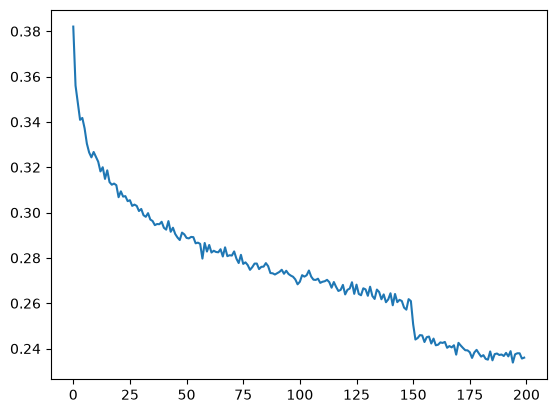

In [395]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1));

In [396]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [397]:
@torch.no_grad() 
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val':   (Xdev, Ydev),
        'test':  (Xte, Yte),
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7006492614746094
val 1.9923914670944214


In [399]:
# sample from the model

for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
        # forward pass the neural Çnet
        logits = model(torch.tensor([context])) # add batch dim!
        probs = F.softmax(logits, dim=1)

        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()

        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)

        # if we sample the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))  # decode and print the generated word

nirel.
genovis.
alexandra.
jessama.
amazyah.
saream.
quincey.
aeden.
cassan.
nayuto.
jaylin.
shaliah.
zailina.
hofie.
bradit.
elexzander.
kalen.
jahmi.
astra.
zia.


In [401]:
# to do: do it with convolutions